# Data & libraries

In [1]:
from miRBench.dataset import list_datasets, get_dataset_df
from matplotlib import pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score
import numpy as np
import numpy.random as rd
from collections import Counter
import pandas as pd

In [2]:
list_datasets()

['AGO2_CLASH_Hejret2023',
 'AGO2_eCLIP_Klimentova2022',
 'AGO2_eCLIP_Manakov2022']

In [3]:
dset = list_datasets()[0]
train = get_dataset_df(dset, split="train")
test = get_dataset_df(dset, split="test")
train.describe()

Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/train/dataset.tsv
Using cached dataset /home/mciach/.miRBench/datasets/14501607/AGO2_CLASH_Hejret2023/test/dataset.tsv


,label,start,end,gene_cluster_ID
count,8193.000000,8.193000e+03,8.193000e+03,8193.000000
mean,0.498474,6.824635e+07,6.824640e+07,2090.481753
std,0.500028,4.997466e+07,4.997466e+07,1240.486084
min,0.000000,3.306000e+03,3.355000e+03,1.000000
25%,0.000000,3.024620e+07,3.024624e+07,1015.000000
50%,0.000000,5.689580e+07,5.689585e+07,2094.000000
75%,1.000000,1.026173e+08,1.026173e+08,3174.000000
max,1.000000,2.416758e+08,2.416758e+08,4188.000000


In [4]:
train_len_select = [len(s)==22 for s in train['noncodingRNA']]
test_len_test = [len(s)==22 for s in test['noncodingRNA']]

In [5]:
train= train.loc[train_len_select]
test = test.loc[test_len_test]

In [6]:
# Based on a simple logistic model from Notebook "Positional logistic regression model on standard SW alignments"
baseline_match_score = 0.724709
baseline_mismatch_score = -0.647892
baseline_gap_score = -0.901264
baseline_alpha = -5.22 

In [7]:
# Priors on alignment parameters for PosAlign functions:
baseline_M = np.zeros((4, 4, 22))   # third coordinate = nt index
for i in range(22):
    baseline_M[...,i] = np.eye(4)*(baseline_match_score - baseline_mismatch_score)
    baseline_M[...,i] += baseline_mismatch_score
baseline_G_miR = np.zeros(21) + baseline_gap_score
baseline_G_gene = np.zeros(22) + baseline_gap_score

# miRAlign imports

In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
import src

In [10]:
import importlib

In [11]:
from src.miralign import miRAlign, logit_logl, logit_lhood_vect
from src.alignment_table_encoding import encode_posloc_fullM, encode_posloc_simple
from src.positional_alignment import pos_aware_align_local

# Gradient descent

In [12]:
importlib.reload(src.miralign)

<module 'src.miralign' from '/home/mciach/Projects/miRNA_optimal_alignments/src/miralign.py'>

In [13]:
importlib.reload(src)

<module 'src' from '/home/mciach/Projects/miRNA_optimal_alignments/src/__init__.py'>

### Full data

In [14]:
from src.miralign import create_subgradient_step

In [15]:
descent_stepfunction = create_subgradient_step(0.001, 0.5, 300)

In [16]:
# newton_stepfunction_fullM = create_newton_step_fullM()

In [17]:
ITER = 200

In [18]:
# Iter 1
# Current loglik: -2443.8629490973267
# Updated alpha: -5.23515879598348
# M subgradient norm: 155.5059521472122
# G_miR subgradient norm: 35.16881324065914
# G_gene subgradient norm: 28.813154109228204
# Iter 2
# Current loglik: -2420.362995902762
# Updated alpha: -5.210766083991661
# M subgradient norm: 132.31762066168895
# G_miR subgradient norm: 37.6950818139548
# G_gene subgradient norm: 23.969519182547355
# Iter 3
# Current loglik: -2401.8686172711496
# Updated alpha: -5.195312737795673
# M subgradient norm: 119.15460378644427
# G_miR subgradient norm: 36.214108368558335
# G_gene subgradient norm: 24.146727314701277

In [19]:
theta = miRAlign(train, test, 
        pos_aware_align_local,
        descent_stepfunction,
        label_observation_parameters = np.array([[900, 100], [100, 900]]),
        verbose=False,         
        M_prior = baseline_M, 
        G_miR_prior = baseline_G_miR,
        G_gene_prior = baseline_G_gene, 
        lbd = 5,
        MAX_ITER = ITER
        )

In [20]:
print('Final LogLik', theta['LogLik_final'])
print('Final train score', theta['train_scores'][-1])
print('Final test score', theta['test_scores'][-1])
print('Final subgradient norm', theta['subgradient_norm_values'][-1])

Final LogLik -2980.407070385562
Final train score 0.8772132445750035
Final test score 0.8467487775290155
Final subgradient norm 9.465446992196107


In [21]:
theta['label_observation_probs']

array([[0.93425568, 0.06574432],
       [0.06936348, 0.93063652]])

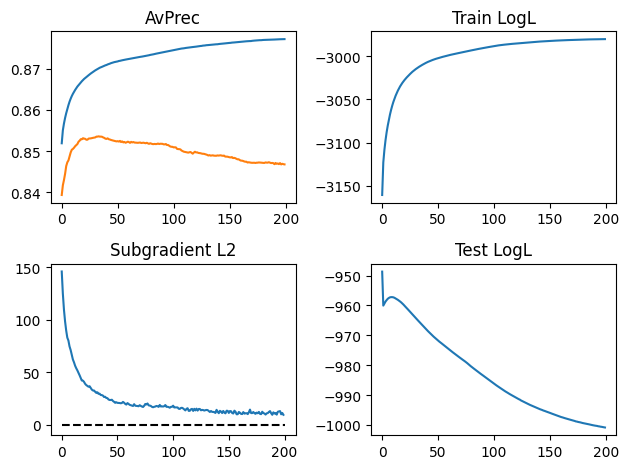

In [22]:
plt.figure()
plt.subplot(221)
plt.title('AvPrec')
plt.plot(np.arange(ITER), theta['train_scores'])
plt.plot(np.arange(ITER), theta['test_scores'])
plt.subplot(222)
plt.title('Train LogL')
plt.plot(np.arange(ITER), theta['train_LogLik_trajectory'])
plt.subplot(223)
plt.title('Subgradient L2')
plt.plot(np.arange(ITER), theta['subgradient_norm_values'])
plt.plot([0, ITER], [0, 0], 'k--')
plt.ylim(ymin=-10)
plt.subplot(224)
plt.title('Test LogL')
plt.plot(np.arange(ITER), theta['test_LogLik_trajectory'])
plt.tight_layout()

In [23]:
M = theta['M']

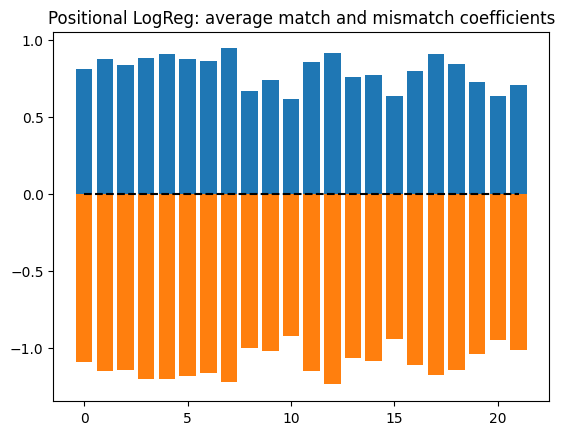

In [24]:
plt.figure()
plt.title('Positional LogReg: average match and mismatch coefficients')
plt.bar(np.arange(22), [np.mean(np.diag(M[...,i])) for i in range(22)])
plt.bar(np.arange(22), [np.mean(M[...,i] - np.diag(M[...,i])) for i in range(22)])
plt.plot([0, 21], [0, 0], 'k--')

In [25]:
fitted_alignments_train = theta['Final_alignments_train']
fitted_alignments_test = theta['Final_alignments_test']

In [26]:
train_scores = np.array([x[0] for x in fitted_alignments_train])

In [27]:
test_scores = np.array([x[0] for x in fitted_alignments_test])

In [28]:
train_L_values = logit_lhood_vect(train_scores, theta['alpha'])
test_L_values = logit_lhood_vect(test_scores, theta['alpha'])

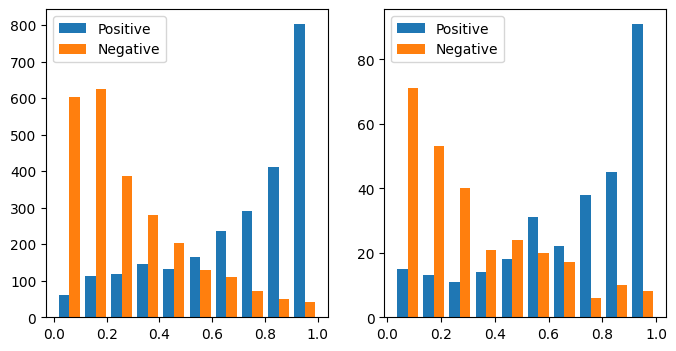

In [29]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist([train_L_values[train['label']==1], train_L_values[train['label']==0]])
plt.legend(['Positive', 'Negative'])
plt.subplot(122)
plt.hist([test_L_values[test['label']==1], test_L_values[test['label']==0]])
plt.legend(['Positive', 'Negative'])
plt.show()

Average precision: 0.8772132445750035


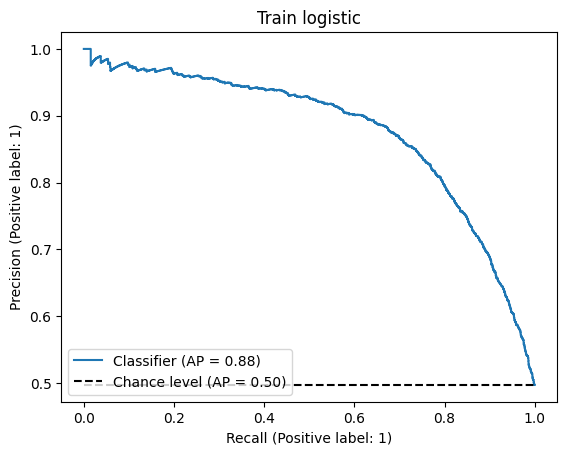

In [30]:
l, s = train['label'], train_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Average precision: 0.8467487775290155


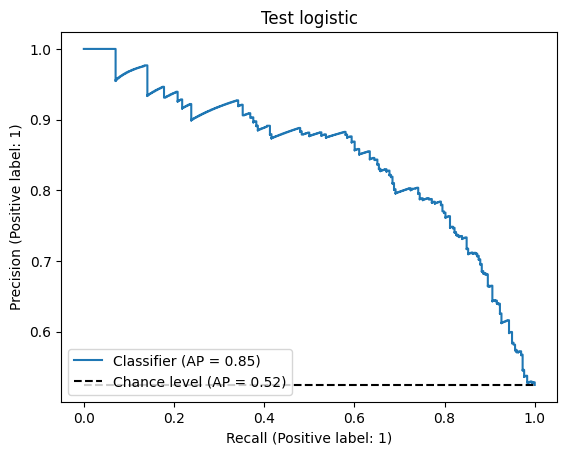

In [31]:
l, s = test['label'], test_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Test logistic')
print('Average precision:', average_precision_score(l, s))

### Check mislabeling probabilities

In [32]:
from src.miralign import get_label_posteriors

In [33]:
fitted_alignments_train = theta['Final_alignments_train']
scores = np.array([x[0] for x in fitted_alignments_train])
scores_pos = scores[train['label']==1]
scores_neg = scores[train['label']==0]

In [34]:
posteriors = get_label_posteriors(scores, train['label'], theta['alpha'], theta['label_observation_probs'])

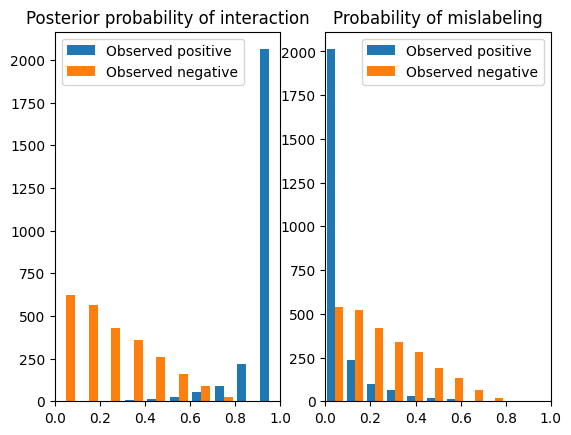

In [35]:
plt.figure()
plt.subplot(121)
plt.title('Posterior probability of interaction')
plt.hist([posteriors[train['label']==1,1], posteriors[train['label']==0,1]])
plt.legend(['Observed positive', 'Observed negative'])
plt.xlim(0,1)
plt.subplot(122)
plt.title('Probability of mislabeling')
plt.hist([posteriors[train['label']==1,0], posteriors[train['label']==0,1]])
plt.legend(['Observed positive', 'Observed negative'])
plt.xlim(0,1)
plt.show()

### Fitting to test data to inspect maximum possible AUPRC

In [ ]:
testtheta = miRAlign(test, train, 
        pos_aware_align_local,
        descent_stepfunction,
         verbose=False,
         MAX_ITER = ITER
        )

In [ ]:
print('Final LogLik', testtheta['LogLik_final'])
print('Final test score', testtheta['test_scores'][-1])
print('Final subgradient norm', testtheta['subgradient_norm_values'][-1])

In [ ]:
plt.figure()
plt.subplot(221)
plt.title('AvPrec')
plt.plot(np.arange(ITER), testtheta['train_scores'])
plt.plot(np.arange(ITER), testtheta['test_scores'])
plt.subplot(222)
plt.title('Train LogL')
plt.plot(np.arange(ITER), testtheta['train_LogLik_trajectory'])
plt.subplot(223)
plt.title('Subgradient L2')
plt.plot(np.arange(ITER), testtheta['subgradient_norm_values'])
plt.subplot(224)
plt.title('Test LogL')
plt.plot(np.arange(ITER), testtheta['test_LogLik_trajectory'])
plt.tight_layout()

In [ ]:
M = testtheta['M']

In [ ]:
plt.figure()
plt.title('Positional LogReg: average match and mismatch coefficients')
plt.bar(np.arange(22), [np.mean(np.diag(M[...,i])) for i in range(22)])
plt.bar(np.arange(22), [np.mean(M[...,i] - np.diag(M[...,i])) for i in range(22)])
plt.plot([0, 21], [0, 0], 'k--')

In [ ]:
testtheta_fitted_alignments_train = testtheta['Final_alignments_train'] # Train = Test
testtheta_fitted_alignments_test = testtheta['Final_alignments_test']   # Test = Train

In [ ]:
testtheta_train_scores = np.array([x[0] for x in testtheta_fitted_alignments_train])

In [ ]:
testtheta_test_scores = np.array([x[0] for x in testtheta_fitted_alignments_test])

In [ ]:
testtheta_train_L_values = logit_lhood_vect(testtheta_train_scores, testtheta['alpha'])
testtheta_test_L_values = logit_lhood_vect(testtheta_test_scores, testtheta['alpha'])

In [ ]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist([testtheta_train_L_values[test['label']==1], testtheta_train_L_values[test['label']==0]])
plt.legend(['Positive', 'Negative'])
plt.subplot(122)
plt.hist([testtheta_test_L_values[train['label']==1], testtheta_test_L_values[train['label']==0]])
plt.legend(['Positive', 'Negative'])
plt.show()

In [ ]:
l, s = test['label'], testtheta_train_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Fitted to Test logistic')
print('Average precision:', average_precision_score(l, s))

In [ ]:
l, s = train['label'], testtheta_test_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Fitted to Test logistic on Train')
print('Average precision:', average_precision_score(l, s))

# Fitting to cleaned data

### CleanLab approach with baseline logistic model

In [ ]:
from src.biopython_alignment import create_fresh_aligner, get_alignments
from src.alignment_table_encoding import encode_biopython_simple
from sklearn.linear_model import LogisticRegression
from cleanlab.classification import CleanLearning

In [ ]:
baseline_params = np.array([5, -4, -6])
baseline_aligner = create_fresh_aligner(*baseline_params)  # match, mismatch, gap

In [ ]:
alignments_train = get_alignments(baseline_aligner, train)

In [ ]:
X_train = encode_biopython_simple(alignments_train)
X_train.index = train.index

In [ ]:
X_train.drop(['0_is_mismatch', '21_is_mismatch', 'intercept'], axis=1, inplace=True)

In [ ]:
logit = LogisticRegression(fit_intercept=True, penalty=None)
clean_logit = CleanLearning(clf=logit)
label_issues = clean_logit.find_label_issues(X_train, train['label'])
issue = label_issues['is_label_issue']

In [ ]:
goodtrain = train[list(~issue)]
badtrain = train[list(issue)]

In [ ]:
goodtheta = miRAlign(goodtrain, test, 
        pos_aware_align_local,
        descent_stepfunction,
         verbose=False,
         MAX_ITER = ITER
        )

In [ ]:
print('Final LogLik', goodtheta['LogLik_final'])
print('Final test score', goodtheta['test_scores'][-1])
print('Final subgradient norm', goodtheta['subgradient_norm_values'][-1])

In [ ]:
plt.figure()
plt.subplot(221)
plt.title('AvPrec')
plt.plot(np.arange(ITER), goodtheta['train_scores'])
plt.plot(np.arange(ITER), goodtheta['test_scores'])
plt.subplot(222)
plt.title('Train LogL')
plt.plot(np.arange(ITER), goodtheta['train_LogLik_trajectory'])
plt.subplot(223)
plt.title('Subgradient L2')
plt.plot(np.arange(ITER), goodtheta['subgradient_norm_values'])
plt.subplot(224)
plt.title('Test LogL')
plt.plot(np.arange(ITER), goodtheta['test_LogLik_trajectory'])
plt.tight_layout()

In [ ]:
M = goodtheta['M']

In [ ]:
plt.figure()
plt.title('Positional LogReg: average match and mismatch coefficients')
plt.bar(np.arange(22), [np.mean(np.diag(M[...,i])) for i in range(22)])
plt.bar(np.arange(22), [np.mean(M[...,i] - np.diag(M[...,i])) for i in range(22)])
plt.plot([0, 21], [0, 0], 'k--')

Check the AUPRC on cleaned train data set and full train and test data sets:

In [ ]:
clean_fitted_alignments_train = goodtheta['Final_alignments_train']
fitted_alignments_test = goodtheta['Final_alignments_test']

In [ ]:
clean_train_scores = np.array([x[0] for x in clean_fitted_alignments_train])
test_scores = np.array([x[0] for x in fitted_alignments_test])

clean_train_L_values = logit_lhood_vect(clean_train_scores, theta['alpha'])
test_L_values = logit_lhood_vect(test_scores, theta['alpha'])

In [ ]:
l, s = goodtrain['label'], clean_train_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('CleanLab Train logistic')
print('Average precision:', average_precision_score(l, s))

In [ ]:
l, s = test['label'], test_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Full Test logistic')
print('Average precision:', average_precision_score(l, s))

In [ ]:
badtheta = miRAlign(badtrain, test, 
        pos_aware_align_local,
        encode_posloc_fullM,
        stepfunction_fullM,
         verbose=False,
         MAX_ITER = 500
        )

In [ ]:
print('Final LogLik', badtheta['LogLik_final'])
print('Final test score', badtheta['test_scores'][-1])

In [ ]:
plt.figure()
plt.subplot(121)
plt.plot(np.arange(500), badtheta['train_scores'])
plt.plot(np.arange(500), badtheta['test_scores'])
plt.subplot(122)
plt.plot(np.arange(500), badtheta['LogLik_trajectory'])
plt.tight_layout()

In [ ]:
M = badtheta['M']

In [ ]:
plt.figure()
plt.title('Positional LogReg: average match and mismatch coefficients')
plt.bar(np.arange(22), [np.mean(np.diag(M[...,i])) for i in range(22)])
plt.bar(np.arange(22), [np.mean(M[...,i] - np.diag(M[...,i])) for i in range(22)])
plt.plot([0, 21], [0, 0], 'k--')

### Removing conflicts between Hejret and Manakov

In [36]:
hejret_full = pd.read_csv('temp_data/hejret_with_conflict_score.csv')

In [37]:
manakov_conflict_neg = (hejret_full['label'] == 0) & (hejret_full['Max_score_Manakov_pos'] > 25)
manakov_conflict_pos = (hejret_full['label'] == 1) & (hejret_full['Max_score_Manakov_neg'] > 25)
manakov_conflict = manakov_conflict_neg | manakov_conflict_pos

In [38]:
sum(manakov_conflict)

322

In [39]:
hejret_full_clean = hejret_full[~manakov_conflict]

In [40]:
train_clean = hejret_full_clean[hejret_full_clean['Dataset']=='train']
test_clean = hejret_full_clean[hejret_full_clean['Dataset']=='test']

In [41]:
train_len_select = [len(s)==22 for s in train_clean['noncodingRNA']]
test_len_test = [len(s)==22 for s in test_clean['noncodingRNA']]

In [42]:
train_clean = train_clean[train_len_select]
test_clean = test_clean[test_len_test]

In [44]:
noconflict_theta = miRAlign(train_clean, test_clean, 
        pos_aware_align_local,
        descent_stepfunction,
         verbose=False,
        label_observation_parameters = np.array([[900, 10], [100, 90]]),       
        M_prior = baseline_M, 
        G_miR_prior = baseline_G_miR,
        G_gene_prior = baseline_G_gene, 
        lbd = 10,
         MAX_ITER = ITER
        )

In [45]:
print('Final LogLik', noconflict_theta['LogLik_final'])
print('Final test score', noconflict_theta['test_scores'][-1])
print('Final subgradient norm', noconflict_theta['subgradient_norm_values'][-1])

Final LogLik -2530.670825287259
Final test score 0.8608919403432733
Final subgradient norm 8.144986815104414


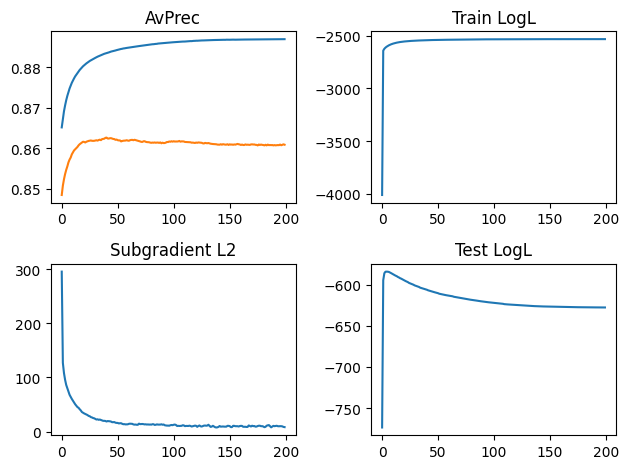

In [46]:
plt.figure()
plt.subplot(221)
plt.title('AvPrec')
plt.plot(np.arange(ITER), noconflict_theta['train_scores'])
plt.plot(np.arange(ITER), noconflict_theta['test_scores'])
plt.subplot(222)
plt.title('Train LogL')
plt.plot(np.arange(ITER), noconflict_theta['train_LogLik_trajectory'])
plt.subplot(223)
plt.title('Subgradient L2')
plt.plot(np.arange(ITER), noconflict_theta['subgradient_norm_values'])
plt.subplot(224)
plt.title('Test LogL')
plt.plot(np.arange(ITER), noconflict_theta['test_LogLik_trajectory'])
plt.tight_layout()

In [47]:
M = noconflict_theta['M']

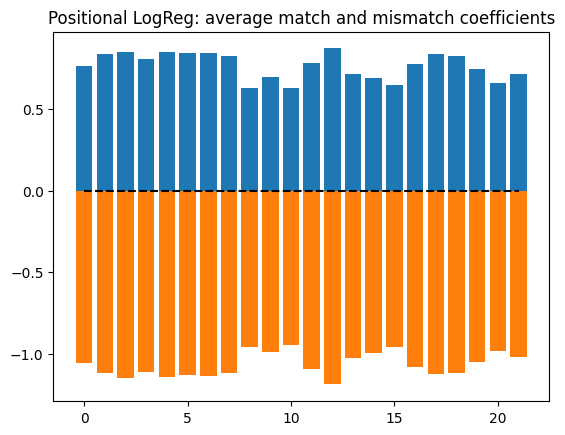

In [48]:
plt.figure()
plt.title('Positional LogReg: average match and mismatch coefficients')
plt.bar(np.arange(22), [np.mean(np.diag(M[...,i])) for i in range(22)])
plt.bar(np.arange(22), [np.mean(M[...,i] - np.diag(M[...,i])) for i in range(22)])
plt.plot([0, 21], [0, 0], 'k--')

In [49]:
fitted_alignments_train = noconflict_theta['Final_alignments_train']
fitted_alignments_test = noconflict_theta['Final_alignments_test']

In [50]:
train_scores = np.array([x[0] for x in fitted_alignments_train])

In [51]:
test_scores = np.array([x[0] for x in fitted_alignments_test])

In [52]:
train_L_values = logit_lhood_vect(train_scores, noconflict_theta['alpha'])
test_L_values = logit_lhood_vect(test_scores, noconflict_theta['alpha'])

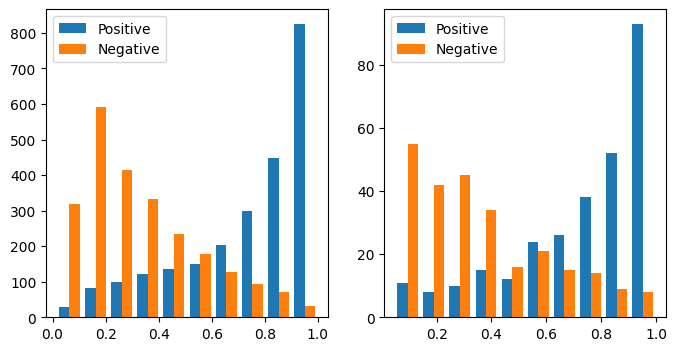

In [53]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist([train_L_values[train_clean['label']==1], train_L_values[train_clean['label']==0]])
plt.legend(['Positive', 'Negative'])
plt.subplot(122)
plt.hist([test_L_values[test_clean['label']==1], test_L_values[test_clean['label']==0]])
plt.legend(['Positive', 'Negative'])
plt.show()

Average precision: 0.8869059597709104


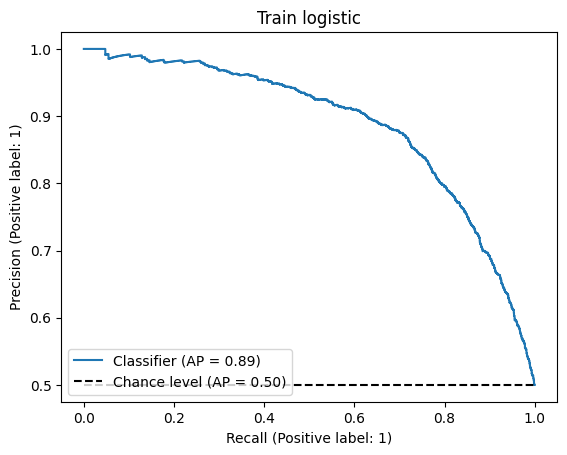

In [54]:
l, s = train_clean['label'], train_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Average precision: 0.8608919403432733


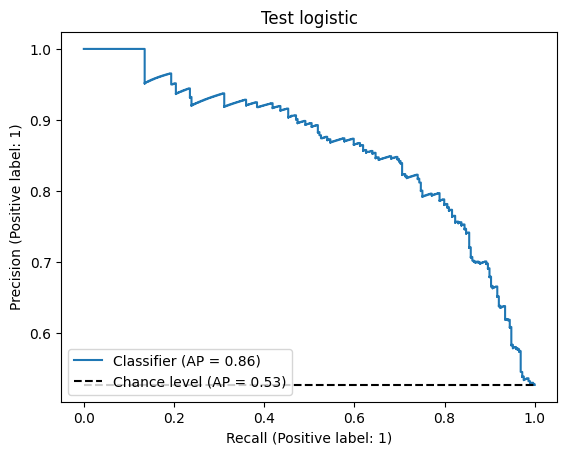

In [55]:
l, s = test_clean['label'], test_L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Test logistic')
print('Average precision:', average_precision_score(l, s))

### Compare with posterior probability of mislabeling

In [56]:
manakov_conflict_train = manakov_conflict[hejret_full['Dataset']=='train']
train_len_select = [len(m) == 22 for m in hejret_full[hejret_full['Dataset']=='train']['noncodingRNA']]
manakov_conflict_train = manakov_conflict_train[train_len_select]

In [57]:
conflict_labels = train['label'][manakov_conflict_train]
conflict_posteriors = posteriors[manakov_conflict_train]

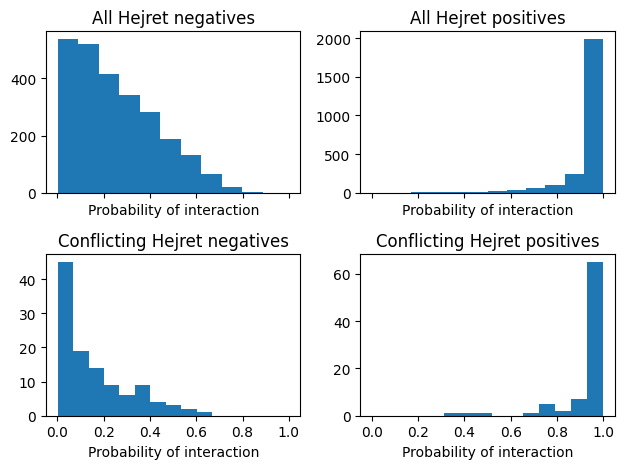

In [58]:
plt.subplots(2, 2, sharex=True)
plt.subplot(221)
plt.title('All Hejret negatives')
plt.hist(posteriors[train['label']==0, 1])
plt.xlabel('Probability of interaction')
plt.subplot(222)
plt.title('All Hejret positives')
plt.hist(posteriors[train['label']==1, 1])
plt.xlabel('Probability of interaction')
plt.subplot(223)
plt.title('Conflicting Hejret negatives')
plt.hist(conflict_posteriors[conflict_labels==0, 1])
plt.xlabel('Probability of interaction')
plt.subplot(224)
plt.title('Conflicting Hejret positives')
plt.hist(conflict_posteriors[conflict_labels==1, 1])
plt.xlabel('Probability of interaction')
plt.tight_layout()

# Analysis of low-likelihood samples 
Using model fitted to cleaned Hejret

In [106]:
from Bio.Seq import Seq

In [113]:
alignments = [pos_aware_align_local(A, Seq(B).reverse_complement(), 
                                        M=noconflict_theta['M'], 
                                        G_miR = noconflict_theta['G_miR'], 
                                        G_gene = noconflict_theta['G_gene'],
                                       backtrack=True) for A, B in zip(train_clean['noncodingRNA'], train_clean['gene'])]

In [136]:
L_values = logit_lhood_vect([s for s, *_ in alignments], noconflict_theta['alpha'])

Average precision: 0.886928474027209


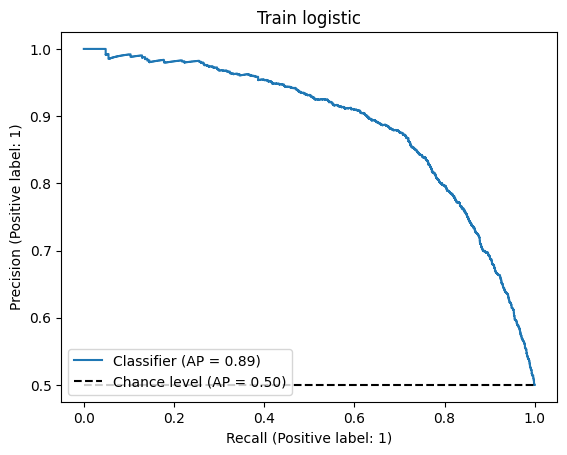

In [140]:
l, s = train_clean['label'], L_values
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

In [221]:
pos_low_L = (L_values < 0.7)*(train_clean['label']==1)
pos_high_L = (L_values > 0.9)*(train_clean['label']==1)
neg_high_L = (L_values > 0.5)*(train_clean['label']==0)
neg_low_L = (L_values < 0.15)*(train_clean['label']==0)

In [222]:
print(sum(pos_low_L), sum(pos_high_L), sum(neg_high_L), sum(neg_low_L))

811 835 517 555


In [163]:
pos_alignments = [aln for aln, lab in zip(alignments, train_clean['label']) if lab == 1]
neg_alignments = [aln for aln, lab in zip(alignments, train_clean['label']) if lab == 0]

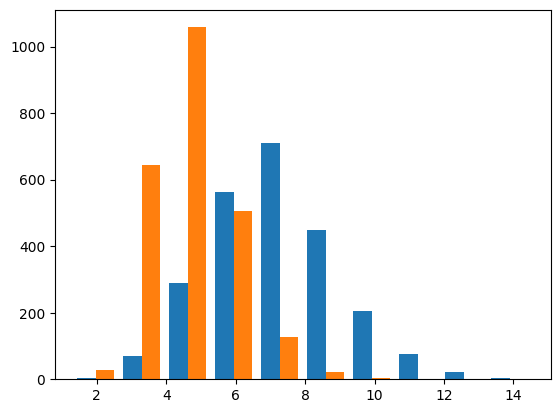

In [164]:
plt.figure()
plt.hist([[s for s, *_ in pos_alignments], [s for s, *_ in neg_alignments]])
plt.show()

Average precision: 0.886928474027209


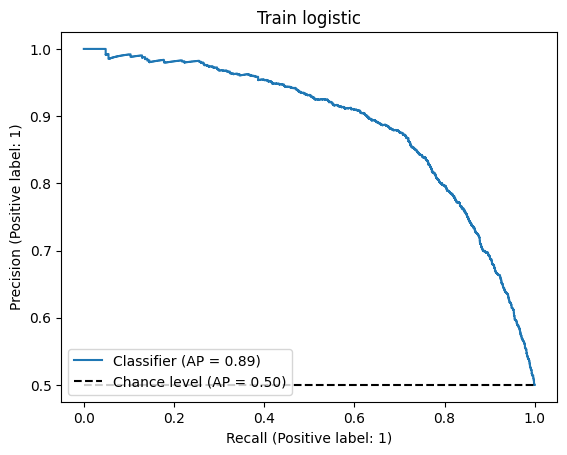

In [165]:
l, s = train_clean['label'], [s for s, *_ in alignments]
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Five random high-scoring and five random low-scoring positive instances:

In [166]:
for high_id in rd.choice(np.where(pos_high_L)[0], 5, replace=False):
    s, miR, G, *_ = alignments[high_id]
    print(high_id)
    print(''.join(train_clean['noncodingRNA'].iloc[high_id]))
    print('miR:  ' + ''.join(miR) + ' score:', s)
    print('Gene: ' + ''.join(G))
    print()

4383
TATTGCACTTGTCCCGGCCTGT
miR:  TATTGCACTTGTCCCG score: 8.754432445205595
Gene: T-TTGCACTTG-CCCG

238
TGAGGTAGGAGGTTGTATAGTT
miR:  TGAGGTAG-GAGGTTGT-ATAGTT score: 12.555484898646808
Gene: TGAGGTAGAGAGGTTGTGATCGCT

3065
TCAGGCTCAGTCCCCTCCCGAT
miR:  TCA-GGCTCAGTCCCCTC-CCG score: 10.570871724632624
Gene: TCAGGGCTC--TCCCCTCTCCG

3755
GTTCTCCCAACGTAAGCCCAGC
miR:  TCTCCC-AACGTAAGCCC-AGC score: 8.009294367125438
Gene: TCACCCCAACG-CAGCCTTAGC

3805
TGCGGGGCTAGGGCTAACAGCA
miR:  GC-GGGGCTAGGGCTAA-CAGC score: 8.387294729877068
Gene: GCAGGGGCCATG-CTAATCATC



In [167]:
for low_id in rd.choice(np.where(pos_low_L)[0], 5, replace=False):
    s, miR, G, *_ = alignments[low_id]
    print(low_id)
    print(''.join(train_clean['noncodingRNA'].iloc[low_id]))
    print('miR:  ' + ''.join(miR) + ' score:', s)
    print('Gene: ' + ''.join(G))
    print()

4272
TATTGCACTTGTCCCGGCCTGT
miR:  TTGCACT--T-GTCCC score: 5.645744642400163
Gene: TTACACTGATAGTCCC

1201
TAGCAGCACGTAAATATTGGCG
miR:  GCAGC-AC score: 4.9935137250709865
Gene: GCAGCTAC

104
TGAGGTAGTAGGTTGTATAGTT
miR:  AGGTAGTAGGTTGTATAG score: 4.888641252067928
Gene: AGGTAC-A-GCTG-A-AG

2228
AAAAGCTGGGTTGAGAGGGCGA
miR:  GCTGGGTTGAGAGGGC score: 5.543174934054332
Gene: GC-GGGTT--G-GGGC

4374
TATTGCACTTGTCCCGGCCTGT
miR:  TAT-TGCAC score: 5.594524260957605
Gene: TATTTGCAC



Alignment features on positive instances:

In [168]:
high_L_alnscores = [x[0] for x, lL in zip(alignments, pos_high_L) if lL]
low_L_alnscores = [x[0] for x, lL in zip(alignments, pos_low_L) if lL]
high_L_alnlens = [len(x[1]) for x, lL in zip(alignments, pos_high_L) if lL]
low_L_alnlens = [len(x[1]) for x, lL in zip(alignments, pos_low_L) if lL]
high_L_alnstarts = [x[3][0] for x, lL in zip(alignments, pos_high_L) if lL]
low_L_alnstarts = [x[3][0] for x, lL in zip(alignments, pos_low_L) if lL]
all_alnlens =  [len(x[1]) for x in alignments]

In [169]:
sum(pos_low_L)

811

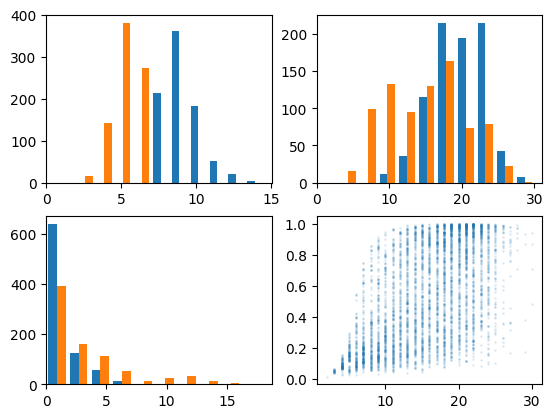

In [176]:
plt.figure()
plt.subplot(221)
plt.hist([high_L_alnscores, low_L_alnscores])
plt.xlim(xmin=0)
plt.subplot(222)
plt.hist([high_L_alnlens, low_L_alnlens])
plt.xlim(xmin=0)
plt.subplot(223)
plt.hist([high_L_alnstarts, low_L_alnstarts])
plt.xlim(xmin=0)
plt.subplot(224)
plt.scatter(all_alnlens, L_values, alpha=0.1, s=1)


On negative instances:

In [223]:
neghigh_L_alnscores = [x[0] for x, lL in zip(alignments, neg_high_L) if lL]
neglow_L_alnscores = [x[0] for x, lL in zip(alignments, neg_low_L) if lL]
neghigh_L_alnlens = [len(x[1]) for x, lL in zip(alignments, neg_high_L) if lL]
neglow_L_alnlens = [len(x[1]) for x, lL in zip(alignments, neg_low_L) if lL]
neghigh_L_alnstarts = [x[3][0] for x, lL in zip(alignments, neg_high_L) if lL]
neglow_L_alnstarts = [x[3][0] for x, lL in zip(alignments, neg_low_L) if lL]
all_alnlens =  [len(x[1]) for x in alignments]

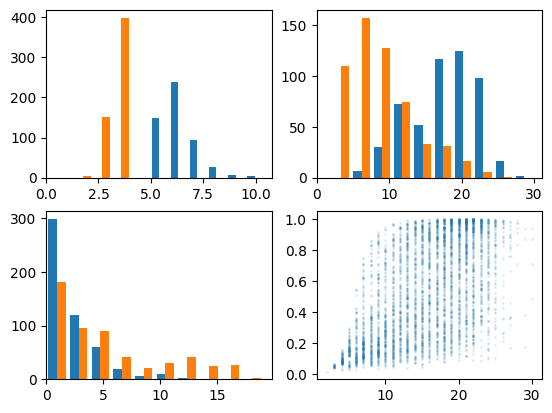

In [224]:
plt.figure()
plt.subplot(221)
plt.hist([neghigh_L_alnscores, neglow_L_alnscores])
plt.xlim(xmin=0)
plt.subplot(222)
plt.hist([neghigh_L_alnlens, neglow_L_alnlens])
plt.xlim(xmin=0)
plt.subplot(223)
plt.hist([neghigh_L_alnstarts, neglow_L_alnstarts])
plt.xlim(xmin=0)
plt.subplot(224)
plt.scatter(all_alnlens, L_values, alpha=0.1, s=1)


In [133]:
train_L_values[312]

0.07058520379619276

In [135]:
L_values[312]

0.9344797161094652

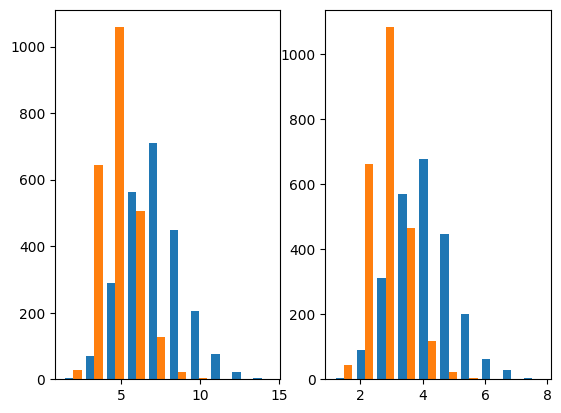

In [180]:
plt.figure()
plt.subplot(121)
plt.hist([[s for s, *_ in pos_alignments], [s for s, *_ in neg_alignments]])
plt.subplot(122)
plt.hist([[x[0]/len(x[1])**0.2 for x in pos_alignments], [x[0]/len(x[1])**0.2 for x in neg_alignments]])
plt.show()

Average precision: 0.8882742454617654


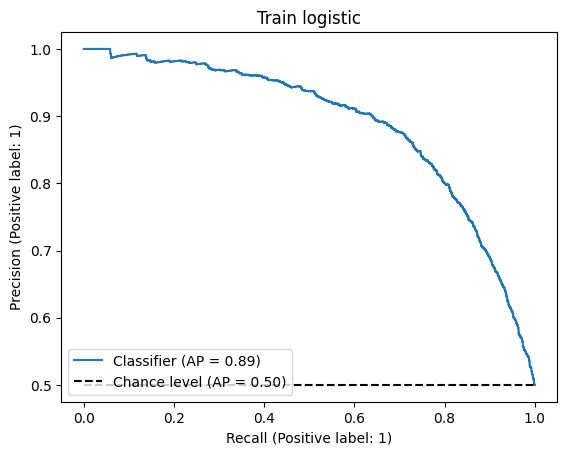

In [200]:
l, s = train_clean['label'], [x[0]/len(x[1])**0.07 for x in alignments]
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

Average precision: 0.8883379416283497


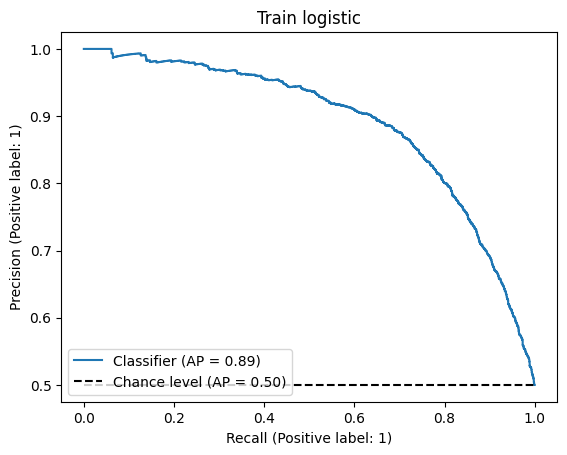

In [211]:
l, s = train_clean['label'], [x[0]/np.log(35+len(x[1])) for x in alignments]
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

In [310]:
from src.alignment_table_encoding import encode_posloc_simple

In [265]:
Xpos = encode_posloc_simple(pos_alignments)
Xneg = encode_posloc_simple(neg_alignments)

In [266]:
neg_lens = Xneg.iloc[:, :-1].sum(axis=1)
neg_matchnbs = Xneg[[c for c in Xneg if 'is_match' in c]].sum(axis=1)
pos_lens = Xpos.iloc[:, :-1].sum(axis=1)
pos_matchnbs = Xpos[[c for c in Xpos if 'is_match' in c]].sum(axis=1)

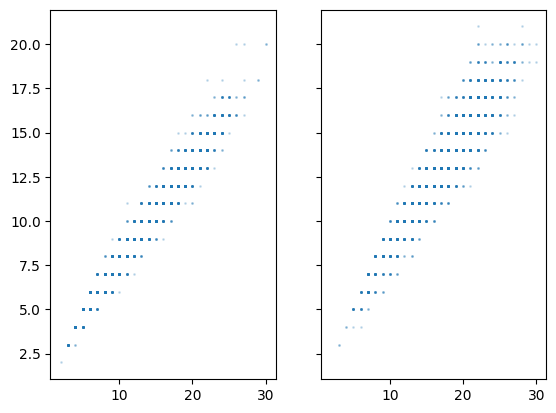

In [270]:
plt.subplots(1, 2, sharex=True, sharey=True)
plt.subplot(121)
plt.scatter(neg_lens, neg_matchnbs, alpha=0.2, s=1)
plt.subplot(122)
plt.scatter(pos_lens, pos_matchnbs, alpha=0.2, s=1)

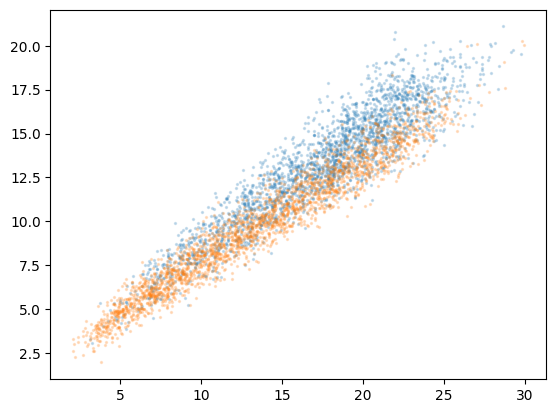

In [291]:
plt.figure()
jitter = 0.4
plt.scatter(pos_lens+rd.normal(size=len(pos_lens), scale=jitter), 
            pos_matchnbs +rd.normal(size=len(pos_matchnbs), scale=jitter), alpha=0.2, s=2)
plt.scatter(neg_lens+rd.normal(size=len(neg_lens), scale=jitter), 
            neg_matchnbs+rd.normal(size=len(neg_matchnbs), scale=jitter), alpha=0.2, s=2)


In [296]:
all_lens = pd.concat((pos_lens, neg_lens))
all_matches = pd.concat((pos_matchnbs, neg_matchnbs))
all_labels = [1]*len(pos_lens) + [0]*len(neg_lens)
logitX = pd.DataFrame({'Lens': all_lens, 'Matches': all_matches})

In [294]:
from sklearn.linear_model import LogisticRegression

In [295]:
logit = LogisticRegression(fit_intercept=True)

In [297]:
logit.fit(logitX, all_labels)

LogisticRegression()

In [302]:
logit.coef_

array([[-0.71511893,  1.4164081 ]])

In [303]:
logit.intercept_

array([-5.05026512])

In [301]:
logit.predict_proba(logitX)

array([[0.00878145, 0.99121855],
       [0.83949257, 0.16050743],
       [0.55582121, 0.44417879],
       ...,
       [0.90659644, 0.09340356],
       [0.55582121, 0.44417879],
       [0.22313188, 0.77686812]])

Average precision: 0.8597060804241059


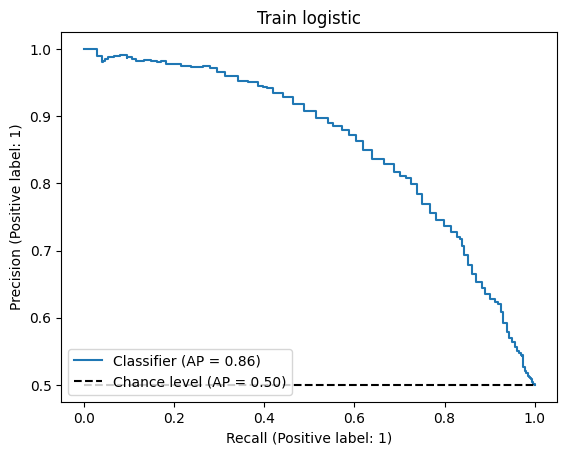

In [309]:
l, s = all_labels, logit.predict_proba(logitX)[:,1]
display = PrecisionRecallDisplay.from_predictions(
    l,
    s, 
    plot_chance_level=True, pos_label=1
)
_ = display.ax_.set_title('Train logistic')
print('Average precision:', average_precision_score(l, s))

In [321]:
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)

In [322]:
km.fit(Xpos.drop(['intercept'], axis=1))

/home/mciach/Py3Env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3)

In [323]:
km.cluster_centers_

array([[0.34206081, 0.        , 0.51773649, 0.03631757, 0.58361486,
        0.06081081, 0.65118243, 0.07094595, 0.72212838, 0.06756757,
        0.73141892, 0.10135135, 0.73648649, 0.11824324, 0.74915541,
        0.10472973, 0.57516892, 0.19003378, 0.64864865, 0.17905405,
        0.61148649, 0.16638514, 0.66722973, 0.12584459, 0.61908784,
        0.10641892, 0.58868243, 0.09206081, 0.52364865, 0.09206081,
        0.41554054, 0.11908784, 0.44594595, 0.08108108, 0.40287162,
        0.06334459, 0.37415541, 0.03800676, 0.27280405, 0.03209459,
        0.18496622, 0.02364865, 0.11908784, 0.        , 0.47635135,
        0.41976351],
       [0.45580589, 0.        , 0.6135182 , 0.03639515, 0.65337955,
        0.06759099, 0.70017331, 0.09358752, 0.79376083, 0.06932409,
        0.82842288, 0.09358752, 0.83188908, 0.09358752, 0.85268631,
        0.10398614, 0.72443674, 0.18370884, 0.79376083, 0.17157712,
        0.73483536, 0.20450607, 0.80589255, 0.16811092, 0.84055459,
        0.10918544, 0.80415

<BarContainer object of 46 artists>

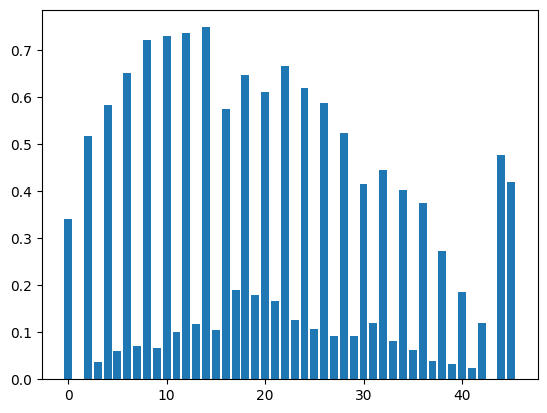

In [324]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[0])), km.cluster_centers_[0])

<BarContainer object of 46 artists>

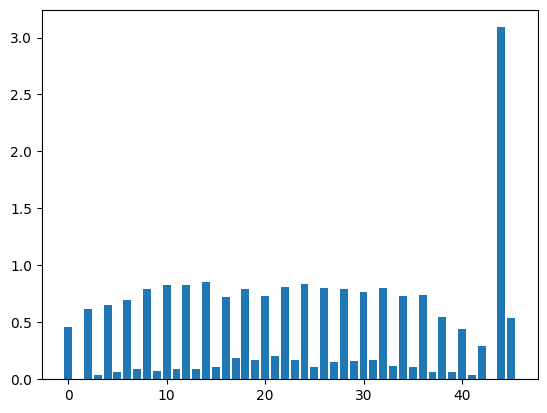

In [325]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[1])), km.cluster_centers_[1])

<BarContainer object of 46 artists>

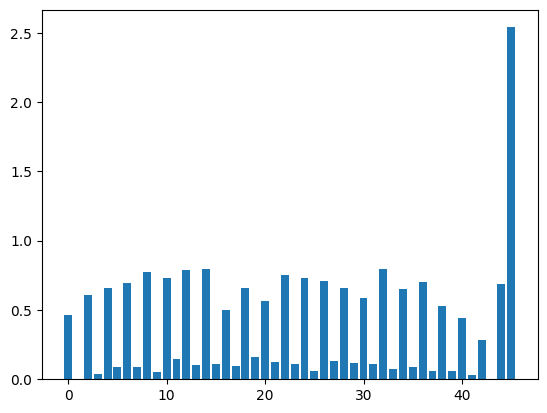

In [326]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[2])), km.cluster_centers_[2])

In [341]:
km = KMeans(n_clusters=3)
km.fit(Xpos.drop(['intercept', 'Gap_miR', 'Gap_gene'], axis=1))

/home/mciach/Py3Env/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=3)

<BarContainer object of 44 artists>

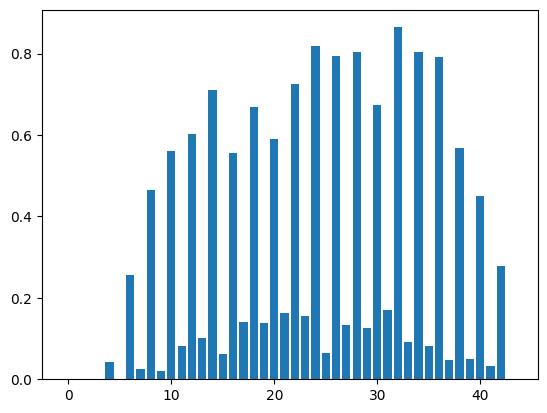

In [348]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[0])), km.cluster_centers_[0])

<BarContainer object of 44 artists>

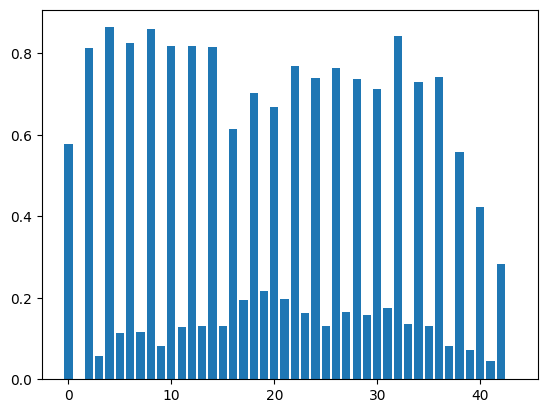

In [349]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[1])), km.cluster_centers_[1])

<BarContainer object of 44 artists>

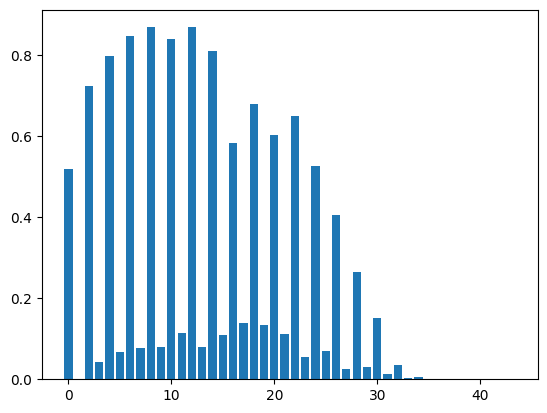

In [350]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[2])), km.cluster_centers_[2])

In [347]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[3])), km.cluster_centers_[3])

IndexError: index 3 is out of bounds for axis 0 with size 3

<Figure size 640x480 with 0 Axes>

<BarContainer object of 44 artists>

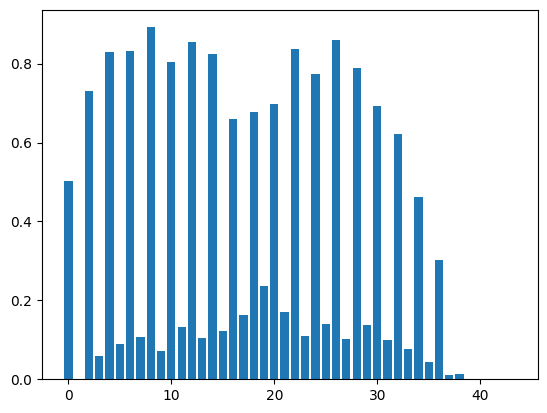

In [340]:
plt.figure()
plt.bar(np.arange(len(km.cluster_centers_[4])), km.cluster_centers_[4])